# Data Description and Problem Statement 

In the U.S., every hospital that receives payments from Medicare and Medicaid is mandated to provide quality data to The Centers for Medicare and Medicaid Services (CMS) annually. This data helps gauge patient satisfaction levels across the country. While overall hospital scores can be influenced by the quality of customer services, there may also be variations in satisfaction based on the type of hospital or its location.

**Year**: 2016 - 2020

The Star Rating Program, implemented by The Centers for Medicare & Medicaid Services (CMS), employs a five-star grading system to evaluate the experiences of Medicare beneficiaries with their respective health plans and the overall healthcare system. Health plans receive scores ranging from 1 to 5 stars, with 5 stars denoting the highest quality.

**Benefits**:

Historical Analysis: With data spanning from 2016 to 2020, researchers and analysts can observe trends over time, understanding how patient satisfaction has evolved over these years.

**Benchmarking**: Hospitals can compare their performance against national averages or against peer institutions to see where they stand.

**Identifying Areas for Improvement**: By analyzing specific metrics and feedback, hospitals can pinpoint areas where their services may be lacking and need enhancement.

**Policy and Decision Making**: Governments and healthcare administrators can use the data to make informed decisions about healthcare policies, funding allocations, and other strategic decisions.

**Research and Academic Purposes**: Academics and researchers can use the dataset for various studies, including correlational studies, predictions, and more.

**Geographical Insights**: The dataset may provide insights into regional variations in patient satisfaction, helping to identify areas or states with particularly high or low scores.

**Understanding Factors Affecting Satisfaction**: By correlating satisfaction scores with other variables (e.g., hospital type, size, location), it might be possible to determine which factors play the most significant role in patient satisfaction.

Performance Evaluation: Hospitals can use the data to evaluate the efficacy of any interventions or changes they've made over the years in terms of improving patient satisfaction.

**Enhancing Patient Trust**: Demonstrating transparency and a commitment to improvement can enhance patient trust and loyalty.

**Informed Patients**: By making such data publicly available, potential patients can make more informed decisions about where to seek care based on the satisfaction ratings of previous patients.

Dataset_link: https://data.cms.gov/provider-data/archived-data/hospitals 


# Import Libraries and Dataset

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
import statistics as sts
import warnings
warnings.filterwarnings('ignore')
import glob

In [2]:
path = r"C:\Users\lenovo\Downloads\patient_satisfaction\*.csv"

In [3]:
files= glob.glob(path) # used glob for reading all the matching files as all files are given separately

In [4]:
print(files)

['C:\\Users\\lenovo\\Downloads\\patient_satisfaction\\cms_hospital_patient_satisfaction_2016.csv', 'C:\\Users\\lenovo\\Downloads\\patient_satisfaction\\cms_hospital_patient_satisfaction_2017.csv', 'C:\\Users\\lenovo\\Downloads\\patient_satisfaction\\cms_hospital_patient_satisfaction_2018.csv', 'C:\\Users\\lenovo\\Downloads\\patient_satisfaction\\cms_hospital_patient_satisfaction_2019.csv', 'C:\\Users\\lenovo\\Downloads\\patient_satisfaction\\cms_hospital_patient_satisfaction_2020.csv']


In [5]:
df_list = [pd.read_csv(file) for file in files]
df = pd.concat(df_list, ignore_index=True) # for concatinating all the files 

In [6]:
pd.set_option('display.max_columns',None)

# DATA EXPLORATION

In [7]:
df.head()

,Facility ID,Facility Name,Address,City,State,ZIP Code,County Name,Phone Number,HCAHPS Measure ID,HCAHPS Question,HCAHPS Answer Description,Patient Survey Star Rating,Patient Survey Star Rating Footnote,HCAHPS Answer Percent,HCAHPS Answer Percent Footnote,HCAHPS Linear Mean Value,Number of Completed Surveys,Number of Completed Surveys Footnote,Survey Response Rate Percent,Survey Response Rate Percent Footnote,Start Date,End Date,Year,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for promoting interoperability of EHRs,Hospital overall rating,Hospital overall rating footnote,Mortality national comparison,Mortality national comparison footnote,Safety of care national comparison,Safety of care national comparison footnote,Readmission national comparison,Readmission national comparison footnote,Patient experience national comparison,Patient experience national comparison footnote,Effectiveness of care national comparison,Effectiveness of care national comparison footnote,Timeliness of care national comparison,Timeliness of care national comparison footnote,Efficient use of medical imaging national comparison,Efficient use of medical imaging national comparison footnote
0,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_STAR_RATING,Summary star rating,Summary star rating,3,NaN,Not Applicable,NaN,Not Applicable,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,Same as the National average,NaN,Above the National average,NaN,Same as the National average,NaN,Below the National average,NaN,Same as the National average,NaN,Same as the National average,NaN,Same as the National average,NaN
1,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_CLEAN_HSP_A_P,Patients who reported that their room and bath...,"Room was ""always"" clean",Not Applicable,NaN,65,NaN,Not Applicable,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,Same as the National average,NaN,Above the National average,NaN,Same as the National average,NaN,Below the National average,NaN,Same as the National average,NaN,Same as the National average,NaN,Same as the National average,NaN
2,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_CLEAN_HSP_SN_P,Patients who reported that their room and bath...,"Room was ""sometimes"" or ""never"" clean",Not Applicable,NaN,12,NaN,Not Applicable,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,Same as the National average,NaN,Above the National average,NaN,Same as the National average,NaN,Below the National average,NaN,Same as the National average,NaN,Same as the National average,NaN,Same as the National average,NaN
3,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_CLEAN_HSP_U_P,Patients who reported that their room and bath...,"Room was ""usually"" clean",Not Applicable,NaN,23,NaN,Not Applicable,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,Same as the National average,NaN,Above the National average,NaN,Same as the National average,NaN,Below the National average,NaN,Same as the National average,NaN,Same as the National average,NaN,Same as the National average,NaN
4,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_CLEAN_LINEAR_SCORE,Cleanliness - linear mean score,Cleanliness - linear mean score,Not Applicable,NaN,Not Applicable,NaN,84,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,Same as the National average,NaN,Above the National average,NaN,Same as the National average,NaN,Below the National average,NaN,Same as the National a

In [8]:
df.tail()

,Facility ID,Facility Name,Address,City,State,ZIP Code,County Name,Phone Number,HCAHPS Measure ID,HCAHPS Question,HCAHPS Answer Description,Patient Survey Star Rating,Patient Survey Star Rating Footnote,HCAHPS Answer Percent,HCAHPS Answer Percent Footnote,HCAHPS Linear Mean Value,Number of Completed Surveys,Number of Completed Surveys Footnote,Survey Response Rate Percent,Survey Response Rate Percent Footnote,Start Date,End Date,Year,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for promoting interoperability of EHRs,Hospital overall rating,Hospital overall rating footnote,Mortality national comparison,Mortality national comparison footnote,Safety of care national comparison,Safety of care national comparison footnote,Readmission national comparison,Readmission national comparison footnote,Patient experience national comparison,Patient experience national comparison footnote,Effectiveness of care national comparison,Effectiveness of care national comparison footnote,Timeliness of care national comparison,Timeliness of care national comparison footnote,Efficient use of medical imaging national comparison,Efficient use of medical imaging national comparison footnote
1653678,670130,SOUTHCROSS HOSPITAL,4243 EAST SOUTHCROSS BLVD SUITE 100,SAN ANTONIO,TX,78222,BEXAR,(210) 507-4392,H_RECMND_DY,"Patients who reported YES, they would definite...","""YES"", patients would definitely recommend the...",Not Applicable,NaN,Not Available,19.0,Not Applicable,Not Available,19,Not Available,19,07/01/2018,06/30/2019,2020,Acute Care Hospitals,Proprietary,Yes,NaN,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0
1653679,670130,SOUTHCROSS HOSPITAL,4243 EAST SOUTHCROSS BLVD SUITE 100,SAN ANTONIO,TX,78222,BEXAR,(210) 507-4392,H_RECMND_PY,"Patients who reported YES, they would probably...","""YES"", patients would probably recommend the h...",Not Applicable,NaN,Not Available,19.0,Not Applicable,Not Available,19,Not Available,19,07/01/2018,06/30/2019,2020,Acute Care Hospitals,Proprietary,Yes,NaN,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0
1653680,670130,SOUTHCROSS HOSPITAL,4243 EAST SOUTHCROSS BLVD SUITE 100,SAN ANTONIO,TX,78222,BEXAR,(210) 507-4392,H_RECMND_LINEAR_SCORE,Recommend hospital - linear mean score,Recommend hospital - linear mean score,Not Applicable,NaN,Not Applicable,NaN,Not Available,Not Available,19,Not Available,19,07/01/2018,06/30/2019,2020,Acute Care Hospitals,Proprietary,Yes,NaN,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0
1653681,670130,SOUTHCROSS HOSPITAL,4243 EAST SOUTHCROSS BLVD SUITE 100,SAN ANTONIO,TX,78222,BEXAR,(210) 507-4392,H_RECMND_STAR_RATING,Recommend hospital - star rating,Recommend hospital - star rating,Not Available,19.0,Not Applicable,NaN,Not Applicable,Not Available,19,Not Available,19,07/01/2018,06/30/2019,2020,Acute Care Hospitals,Proprietary,Yes,NaN,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0
1653682,670130,SOUTHCROSS HOSPITAL,4243 EAST SOUTHCROSS BLVD SUITE 100,SAN ANTONIO,TX,78222,BEXAR,(210) 507-4392,H_STAR_RATING,Summary star rating,Summary star rating,Not Available,19.0,Not Applicable,NaN,Not Applicable,Not Available,19,Not Available,19,07/01/2018,06/30/2019,2020,Acute Care Hospitals,Proprietary,Yes,NaN,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0,Not Available,19.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1653683 entries, 0 to 1653682
Data columns (total 43 columns):
 #   Column                                                         Non-Null Count    Dtype 
---  ------                                                         --------------    ----- 
 0   Facility ID                                                    1653683 non-null  object
 1   Facility Name                                                  1653683 non-null  object
 2   Address                                                        1653683 non-null  object
 3   City                                                           1653683 non-null  object
 4   State                                                          1653683 non-null  object
 5   ZIP Code                                                       1653683 non-null  int64 
 6   County Name                                                    1651283 non-null  object
 7   Phone Number                                 

In [10]:
df.duplicated().sum()   # it could be true as there as lot of columns with categorical values and the class could be same in different rows.

np.int64(0)

In [11]:
df.columns

Index(['Facility ID', 'Facility Name', 'Address', 'City', 'State', 'ZIP Code',
       'County Name', 'Phone Number', 'HCAHPS Measure ID', 'HCAHPS Question',
       'HCAHPS Answer Description', 'Patient Survey Star Rating',
       'Patient Survey Star Rating Footnote', 'HCAHPS Answer Percent',
       'HCAHPS Answer Percent Footnote', 'HCAHPS Linear Mean Value',
       'Number of Completed Surveys', 'Number of Completed Surveys Footnote',
       'Survey Response Rate Percent', 'Survey Response Rate Percent Footnote',
       'Start Date', 'End Date', 'Year', 'Hospital Type', 'Hospital Ownership',
       'Emergency Services',
       'Meets criteria for promoting interoperability of EHRs',
       'Hospital overall rating', 'Hospital overall rating footnote',
       'Mortality national comparison',
       'Mortality national comparison footnote',
       'Safety of care national comparison',
       'Safety of care national comparison footnote',
       'Readmission national comparison',
      

In [12]:
for col in df.columns:
    print(col, df[col].duplicated().sum())

Facility ID 1645259
Facility Name 1647914
Address 1648493
City 1650676
State 1653627
ZIP Code 1649154
County Name 1652055
Phone Number 1643759
HCAHPS Measure ID 1653585
HCAHPS Question 1653583
HCAHPS Answer Description 1653582
Patient Survey Star Rating 1653676
Patient Survey Star Rating Footnote 1653675
HCAHPS Answer Percent 1653580
HCAHPS Answer Percent Footnote 1653646
HCAHPS Linear Mean Value 1653634
Number of Completed Surveys 1650648
Number of Completed Surveys Footnote 1653646
Survey Response Rate Percent 1653604
Survey Response Rate Percent Footnote 1653646
Start Date 1653678
End Date 1653678
Year 1653678
Hospital Type 1653679
Hospital Ownership 1653672
Emergency Services 1653681
Meets criteria for promoting interoperability of EHRs 1653680
Hospital overall rating 1653677
Hospital overall rating footnote 1653666
Mortality national comparison 1653676
Mortality national comparison footnote 1653670
Safety of care national comparison 1653676
Safety of care national comparison footn

In [13]:
df.isnull().sum() # Dataset has lot of null values will handle it according to the need of the problem.

Facility ID                                                            0
Facility Name                                                          0
Address                                                                0
City                                                                   0
State                                                                  0
ZIP Code                                                               0
County Name                                                         2400
Phone Number                                                           0
HCAHPS Measure ID                                                      0
HCAHPS Question                                                        0
HCAHPS Answer Description                                              0
Patient Survey Star Rating                                             0
Patient Survey Star Rating Footnote                              1576857
HCAHPS Answer Percent                              

In [14]:
df['Patient Survey Star Rating'].unique()

array(['3', 'Not Applicable', '2', '4', '5', 'Not Available', '1'],
      dtype=object)

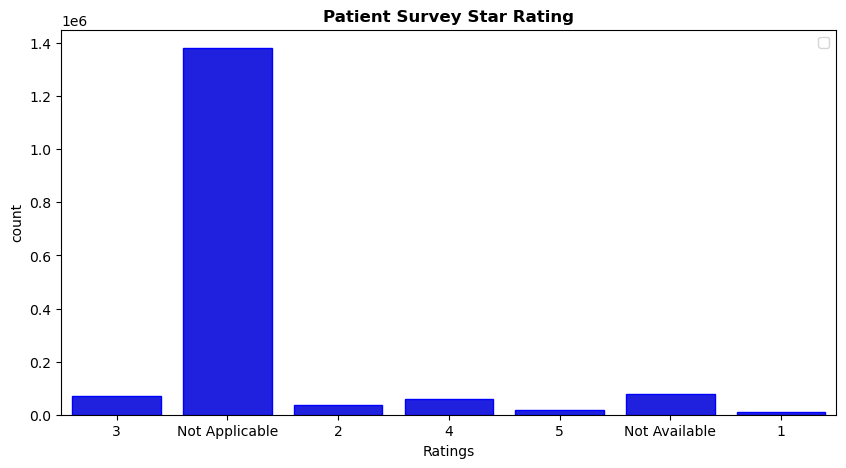

In [15]:
figure=plt.figure(figsize=(10,5))
sns.countplot(data=df , x='Patient Survey Star Rating', color='blue',edgecolor='blue')
plt.title('Patient Survey Star Rating', fontweight='bold')
plt.xlabel('Ratings')
plt.legend(loc='best')
plt.show()

In [16]:
plt.savefig("Patient Survey Star Rating.png")

<Figure size 640x480 with 0 Axes>

#  It can be sharply seen that mostly patient haven't given reviews.Hospitals can focus more on getting rating(reviews) from the customers so that they canimprove on the basis of those reviews in terms of treatment, infrastructure , Emergency services etc.

In [17]:
cols = ['Facility ID', 'ZIP Code','Phone Number']  # these columns are numberic in nature but they are given as string to converted it into numeric.
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [18]:
df.groupby('Year')['Patient Survey Star Rating'].value_counts()

Year  Patient Survey Star Rating
2016  Not Applicable                206701
      Not Available                  15708
      4                              14165
      3                              14041
      2                               8467
      5                               3407
      1                               1896
2017  Not Applicable                206916
      Not Available                  15864
      4                              14735
      3                              14120
      2                               7961
      5                               3413
      1                               1651
2018  Not Applicable                186927
      3                              15941
      Not Available                  14729
      4                              10421
      2                               6440
      5                               3439
      1                               1753
2019  Not Applicable                390074
      Not Available  

 # Value counts of different columns which are needed for the analysis.

In [19]:
df['Patient experience national comparison'].value_counts()

Patient experience national comparison
Not Available                   470302
Above the national average      344048
Same as the national average    332277
Below the national average      317086
Above the National average       66935
Same as the National average     63415
Below the National average       59620
Name: count, dtype: int64

In [20]:
df['Mortality national comparison'].value_counts()

Mortality national comparison
Same as the national average    773391
Not Available                   475429
Same as the National average    150480
Above the national average      112638
Below the national average      100990
Above the National average       22000
Below the National average       18755
Name: count, dtype: int64

In [21]:
df['Safety of care national comparison'].value_counts()

Safety of care national comparison
Not Available                   743722
Above the national average      323806
Below the national average      244584
Same as the national average    195601
Same as the National average     66110
Above the National average       43285
Below the National average       36575
Name: count, dtype: int64

In [22]:
df['Efficient use of medical imaging national comparison'].value_counts()

Efficient use of medical imaging national comparison
Not Available                   633690
Same as the national average    630438
Below the national average      118081
Above the national average      118024
Same as the National average    113245
Below the National average       20515
Above the National average       19690
Name: count, dtype: int64

In [23]:
H_rating=df['Hospital overall rating'].value_counts()
H_rating

Hospital overall rating
3                472382
Not Available    400531
4                367362
2                250984
5                 90684
1                 71740
Name: count, dtype: int64

# In all the above columns (Patient experience national comparison , Mortality national comparison,Safety of care national comparison, Effectiveness of care national comparison ,Efficient use of medical imaging national comparison,Timeliness of care national comparison,Readmission national comparison) data every data point got count twice because some letter uses upper & lower case (In 1st one 'n'is small of national and 'N' is capital in the second one). To rectify this error I have changed these two same classes in the one class.

In [24]:
col_list=['Patient experience national comparison','Mortality national comparison','Safety of care national comparison',
'Effectiveness of care national comparison','Efficient use of medical imaging national comparison','Timeliness of care national comparison','Readmission national comparison']
df[col_list] = df[col_list].apply(
    lambda x: x.str.strip().str.lower())

In [25]:
df.head()

,Facility ID,Facility Name,Address,City,State,ZIP Code,County Name,Phone Number,HCAHPS Measure ID,HCAHPS Question,HCAHPS Answer Description,Patient Survey Star Rating,Patient Survey Star Rating Footnote,HCAHPS Answer Percent,HCAHPS Answer Percent Footnote,HCAHPS Linear Mean Value,Number of Completed Surveys,Number of Completed Surveys Footnote,Survey Response Rate Percent,Survey Response Rate Percent Footnote,Start Date,End Date,Year,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for promoting interoperability of EHRs,Hospital overall rating,Hospital overall rating footnote,Mortality national comparison,Mortality national comparison footnote,Safety of care national comparison,Safety of care national comparison footnote,Readmission national comparison,Readmission national comparison footnote,Patient experience national comparison,Patient experience national comparison footnote,Effectiveness of care national comparison,Effectiveness of care national comparison footnote,Timeliness of care national comparison,Timeliness of care national comparison footnote,Efficient use of medical imaging national comparison,Efficient use of medical imaging national comparison footnote
0,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_STAR_RATING,Summary star rating,Summary star rating,3,NaN,Not Applicable,NaN,Not Applicable,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN
1,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_CLEAN_HSP_A_P,Patients who reported that their room and bath...,"Room was ""always"" clean",Not Applicable,NaN,65,NaN,Not Applicable,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN
2,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_CLEAN_HSP_SN_P,Patients who reported that their room and bath...,"Room was ""sometimes"" or ""never"" clean",Not Applicable,NaN,12,NaN,Not Applicable,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN
3,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_CLEAN_HSP_U_P,Patients who reported that their room and bath...,"Room was ""usually"" clean",Not Applicable,NaN,23,NaN,Not Applicable,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN
4,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_CLEAN_LINEAR_SCORE,Cleanliness - linear mean score,Cleanliness - linear mean score,Not Applicable,NaN,Not Applicable,NaN,84,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,sa

In [26]:
df['Hospital Ownership'].unique()  # all of them are  under govt. undertaking some of them are under  the state , local , federal , Defence and proprietary.

array(['Government - Hospital District or Authority',
       'Voluntary non-profit - Private', 'Proprietary',
       'Government - State', 'Voluntary non-profit - Other',
       'Government - Local', 'Voluntary non-profit - Church',
       'Government - Federal', 'Tribal', 'Physician',
       'Department of Defense'], dtype=object)

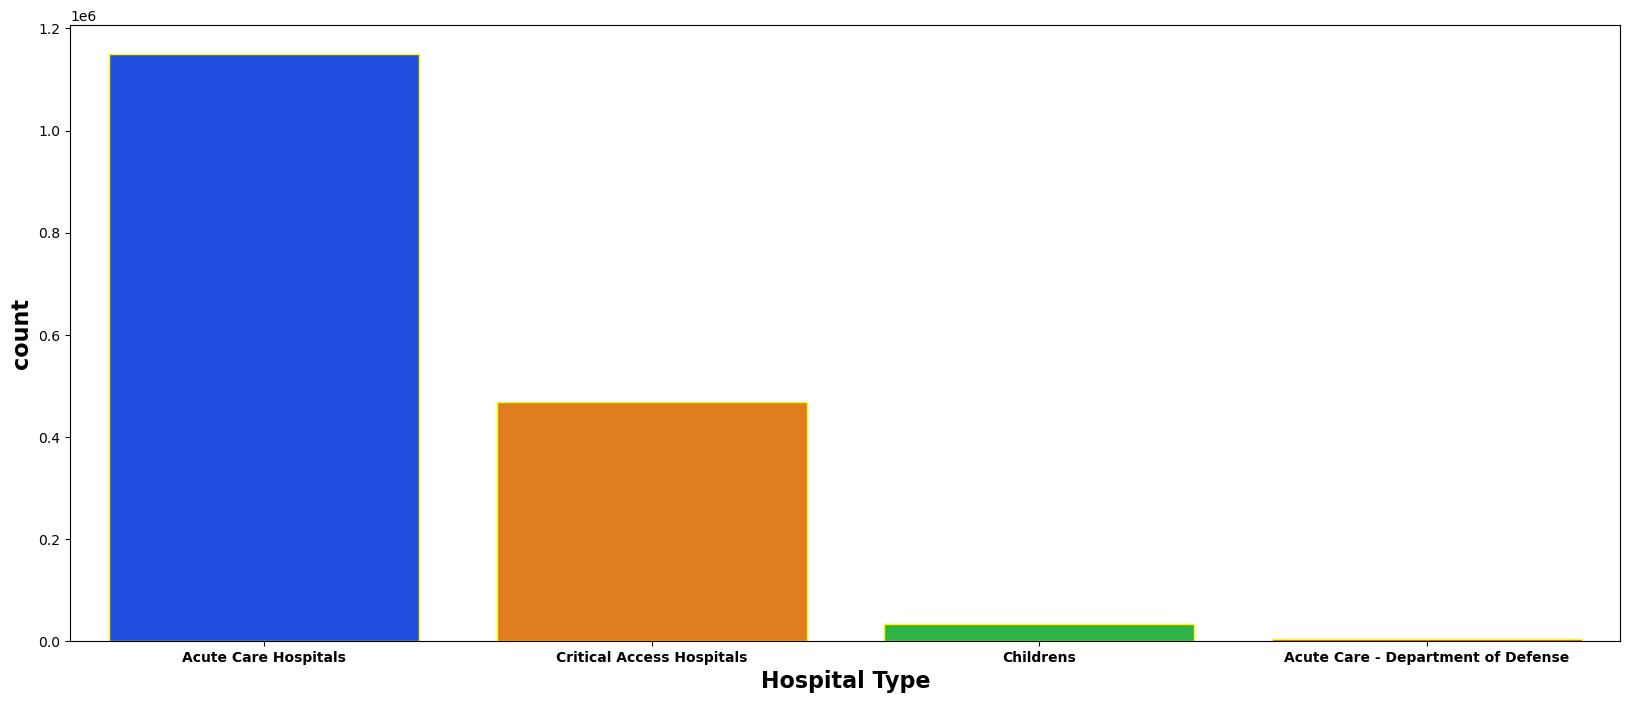

In [27]:
plt.figure(figsize=(20,8))
sns.countplot(data=df , x='Hospital Type',palette='bright',edgecolor='yellow'
             )
plt.xlabel('Hospital Type',fontsize=16 , fontweight='bold')
plt.ylabel('count',fontsize=16 , fontweight='bold')
plt.xticks(fontweight='bold')
plt.show()

 # It can be concluded that maximum number of hospitals are acute care hospitals and the least no of hospitals are acute care-department of Defence.

#  I have created a input based code where anyone can check the number of ratings with respect to the hospital types below :

# Acute Care Hospitals :

In [ ]:
a=str(int(input('enter no b/w 1 to 5:')))
print(f"The Acute Care Hospitals with {a} star ratings are : {df[(df['Hospital Type'] =='Acute Care Hospitals') & (df['Patient Survey Star Rating']==a)].shape[0]}")


# Critical Access Hospitals :

In [ ]:
b=str(int(input('enter no b/w 1 to 5:')))
print(f"The Critical Access Hospitals with {a} star ratings are : {df[(df['Hospital Type'] =='Critical Access Hospitals') & (df['Patient Survey Star Rating']== b)].shape[0]}")


# Children Hospitals :

In [ ]:
c=str(int(input('enter no b/w 1 to 5:')))
print(f"The Childrens Hospitals with star {c} ratings are : {df[(df['Hospital Type'] =='Childrens') & (df['Patient Survey Star Rating'] == c) ].shape[0]}")

In [31]:
df.loc[df['Hospital Type'] =='Childrens'].shape[0] # checked for only verifying total no of childrens hospital type.

33503

# Acute Care - Department of Finance :

In [ ]:
d=str(int(input('enter no b/w 1 to 5:')))
print(f"The Childrens Hospitals with star {a} ratings are : {df[(df['Hospital Type'] =='Acute Care - Department of Defense') & (df['Patient Survey Star Rating']== d)].shape[0]}")

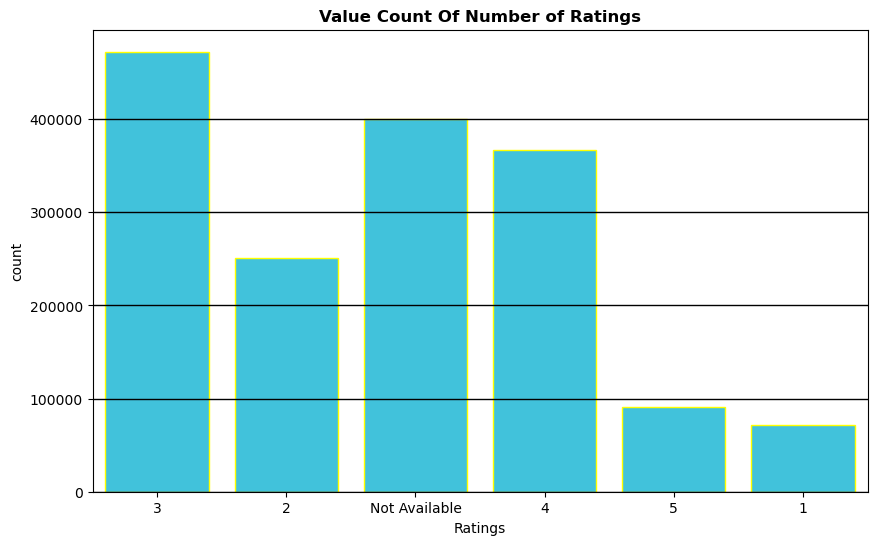

In [33]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Hospital overall rating', color='#27D3F5', edgecolor='yellow')
plt.xlabel('Ratings')
plt.title('Value Count Of Number of Ratings', fontweight='bold')
plt.grid(axis= 'y', linestyle='-' ,linewidth=1 , color ='black')
plt.show()

In [34]:
df['Emergency Services'].unique()

array(['Yes', 'No'], dtype=object)

# Here we can in which Year How many hospital are providing emergency services.

In [ ]:
Y= int(input('Enter the Year (2016-20): '))    
df[(df['Year']== Y ) & (df['Emergency Services']=='Yes')].shape[0]

In [36]:
year_type_counts = pd.crosstab(df['Year'], df['Hospital Type'])
year_type_counts

Hospital Type,Acute Care - Department of Defense,Acute Care Hospitals,Childrens,Critical Access Hospitals
Year,,,,
2016,0,185350,5445,73590
2017,0,185295,5445,73920
2018,0,167350,4850,67450
2019,0,307458,8928,126015
2020,3255,304389,8835,126108


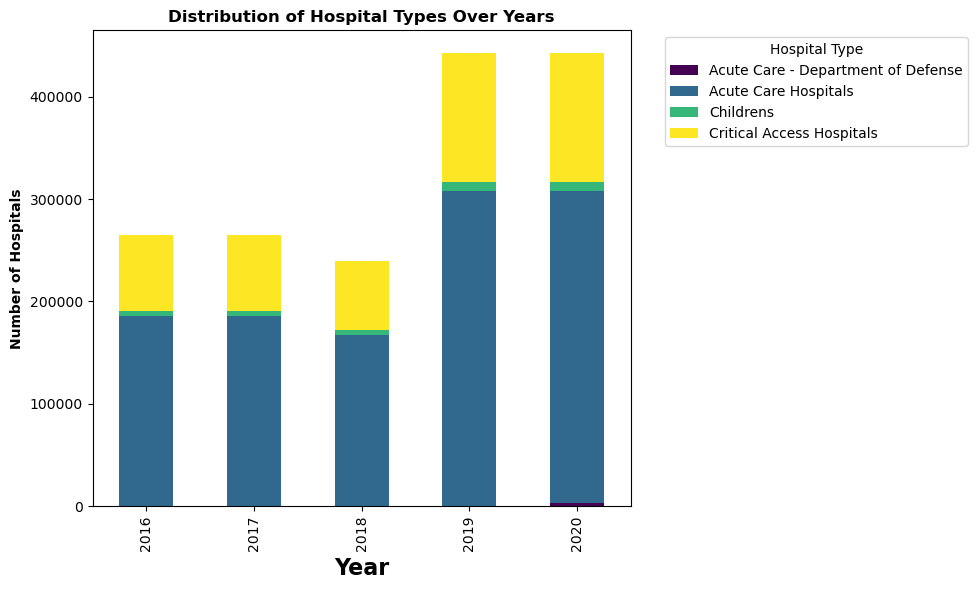

In [37]:
year_type_counts.plot( kind='bar', stacked=True,cmap='viridis',figsize=(10,6))
plt.title('Distribution of Hospital Types Over Years',fontweight='bold')
plt.ylabel('Number of Hospitals',fontweight='bold')
plt.xlabel('Year',fontweight='bold', fontsize=16)
plt.legend(title='Hospital Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# It is concluded from the above data that 'Acute Care - Department of Defense' are built newly in the or operationalize in 2020.The number of 'Acute Care' hospitals are increasing every year and in 2019 its number are increased by appoximately 50%.Children Hospitals are more or less same every year.

In [38]:
df.head()

,Facility ID,Facility Name,Address,City,State,ZIP Code,County Name,Phone Number,HCAHPS Measure ID,HCAHPS Question,HCAHPS Answer Description,Patient Survey Star Rating,Patient Survey Star Rating Footnote,HCAHPS Answer Percent,HCAHPS Answer Percent Footnote,HCAHPS Linear Mean Value,Number of Completed Surveys,Number of Completed Surveys Footnote,Survey Response Rate Percent,Survey Response Rate Percent Footnote,Start Date,End Date,Year,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for promoting interoperability of EHRs,Hospital overall rating,Hospital overall rating footnote,Mortality national comparison,Mortality national comparison footnote,Safety of care national comparison,Safety of care national comparison footnote,Readmission national comparison,Readmission national comparison footnote,Patient experience national comparison,Patient experience national comparison footnote,Effectiveness of care national comparison,Effectiveness of care national comparison footnote,Timeliness of care national comparison,Timeliness of care national comparison footnote,Efficient use of medical imaging national comparison,Efficient use of medical imaging national comparison footnote
0,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_STAR_RATING,Summary star rating,Summary star rating,3,NaN,Not Applicable,NaN,Not Applicable,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN
1,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_CLEAN_HSP_A_P,Patients who reported that their room and bath...,"Room was ""always"" clean",Not Applicable,NaN,65,NaN,Not Applicable,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN
2,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_CLEAN_HSP_SN_P,Patients who reported that their room and bath...,"Room was ""sometimes"" or ""never"" clean",Not Applicable,NaN,12,NaN,Not Applicable,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN
3,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_CLEAN_HSP_U_P,Patients who reported that their room and bath...,"Room was ""usually"" clean",Not Applicable,NaN,23,NaN,Not Applicable,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN
4,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_CLEAN_LINEAR_SCORE,Cleanliness - linear mean score,Cleanliness - linear mean score,Not Applicable,NaN,Not Applicable,NaN,84,1213,NaN,27,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,sa

In [39]:
pivot_table=pd.pivot_table(df , values=['Patient Survey Star Rating'],
                           index=['State'],columns='Year',aggfunc='count')
pivot_table 

Patient Survey Star Rating                            
Year                        2016   2017   2018   2019   2020
State                                                       
AK                          1210   1210   1100   2046   2139
AL                          4895   5005   4550   8277   8184
AR                          4070   4125   3750   7068   7068
AS                            55     55     50     93     93
AZ                          4455   4400   3900   7254   7161
CA                         18755  18865  17050  31620  31806
CO                          4290   4345   4000   7533   7905
CT                          1705   1705   1550   2883   2790
DC                           440    440    400    744    651
DE                           385    385    350    651    651
FL                         10230  10285   9200  17019  17019
GA                          7370   7315   6600  12276  12462
GU                           110    110    100    186    186
HI                          1265   1265   1150   2139   2232
IA                          6380   6380   5800  10788  10788
ID                          2255   2255   2100   3999   3906
IL                          9900   9900   9000  16647  16647
IN                          6600   6600   6000  11160  10881
KS                          7535   7535   6800  12462  12648
KY                          5170   5170   4550   8463   8556
LA                          6710   6655   5950  10788  10602
MA                          3520   3465   3150   5766   5766
MD                          2695   2695   2450   4557   4650
ME                          1815   1815   1650   3069   3069
MI                          7205   7205   6550  12183  12183
MN                          7205   7205   6500  11997  11904
MO                          6270   6160   5600  10323  10323
MP                            55     55     50     93     93
MS                          5280   5225   4750   8835   8928
MT                          3355   3410   3100   5766   5766
NC                          5830   5885   5250   9858  10044
ND                          2420   2420   2200   4092   4092
NE                          4950   4950   4450   8277   8277
NH                          1430   1430   1300   2418   2418
NJ                          3630   3630   3300   6138   6138
NM                          2255   2255   2050   3906   3906
NV                          1815   1925   1750   3348   3441
NY                          9460   9405   8500  15531  15438
OH                          9240   9295   8500  15438  15345
OK                          6765   6710   6150  11067  11067
OR                          3300   3300   3000   5580   5580
PA                          9350   9405   8550  15624  15438
PR                          2860   2915   2600   4836   4836
RI                           605    605    550    930    930
SC                          3300   3300   3000   5580   5487
SD                          3300   3300   2900   5394   5301
TN                          5995   5885   5400   9765   9393
TX                         22385  22550  20450  37293  37107
UT                          2530   2475   2300   4371   4371
VA                          4785   4730   4250   7812   8091
VI                           110    110    100    186    186
VT                           770    770    700   1302   1302
WA                          5005   5005   4500   8463   8742
WI                          6930   6930   6300  11439  11532
WV                          2695   2695   2450   4557   4557
WY                          1485   1540   1400   2511   2511

# We can clearly see here the state wise patient rating has evolved over the year positively.

In [40]:
df['Hospital overall rating'] = pd.to_numeric(df['Hospital overall rating'],errors='coerce')

In [41]:
df.groupby('Hospital Type')['Hospital overall rating'].agg(['count', 'size'])

,count,size
Hospital Type,,
Acute Care - Department of Defense,0,3255
Acute Care Hospitals,1029394,1149842
Childrens,0,33503
Critical Access Hospitals,223758,467083


In [42]:
avg_rating=df.groupby('Hospital Type')['Hospital overall rating'].mean()
avg_rating

Hospital Type
Acute Care - Department of Defense         NaN
Acute Care Hospitals                  3.049300
Childrens                                  NaN
Critical Access Hospitals             3.462629
Name: Hospital overall rating, dtype: float64

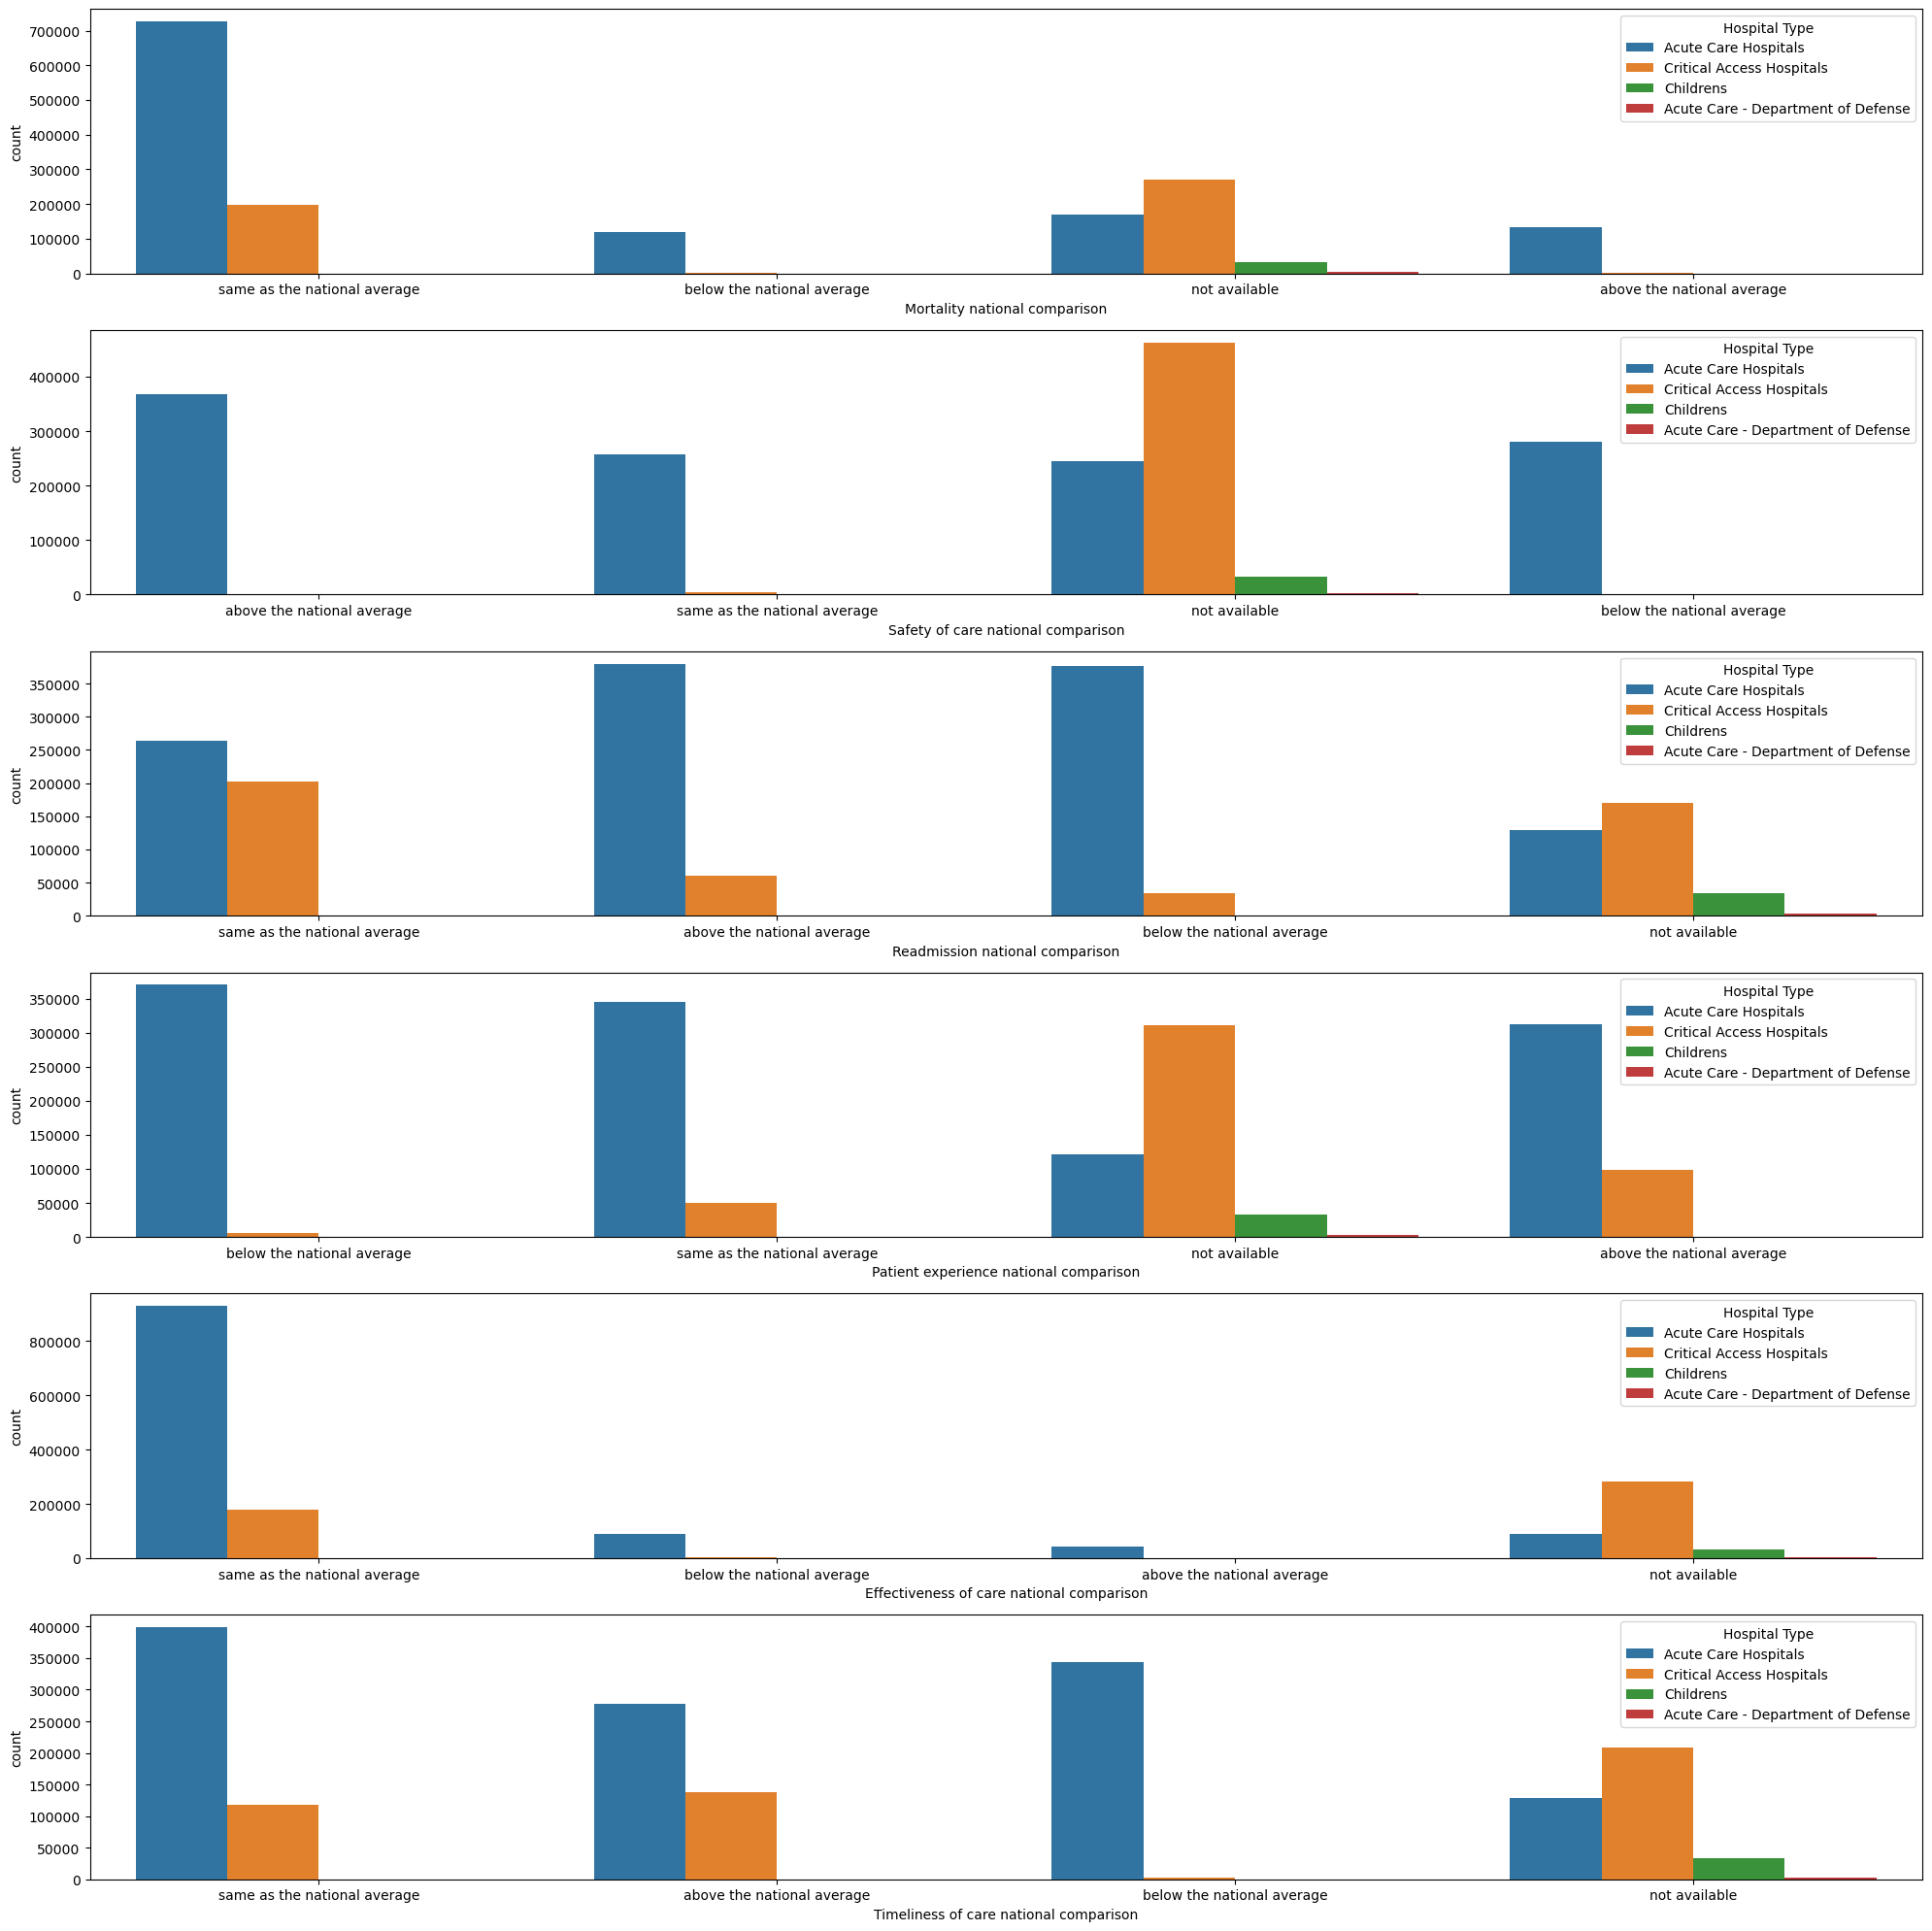

In [43]:
plt.figure(figsize=(20,20))
plt.subplot(611) 
sns.countplot(data=df , x='Mortality national comparison', hue='Hospital Type')

plt.subplot(612) 
sns.countplot(data=df , x='Safety of care national comparison',hue='Hospital Type')

plt.subplot(613) 
sns.countplot(data=df , x='Readmission national comparison',hue='Hospital Type')

plt.subplot(614) 
sns.countplot(data=df , x='Patient experience national comparison',hue='Hospital Type')

plt.subplot(615) 
sns.countplot(data=df , x='Effectiveness of care national comparison',hue='Hospital Type')

plt.subplot(616) 
sns.countplot(data=df , x='Timeliness of care national comparison',hue='Hospital Type')
plt.tight_layout()

plt.show()



In [44]:
df['Survey Response Rate Percent'] = pd.to_numeric(df['Survey Response Rate Percent'], errors='coerce')
df = df.dropna(subset=['Survey Response Rate Percent'])
state_avg = df.groupby('State')['Survey Response Rate Percent'].mean().reset_index()
fig = px.choropleth(
    state_avg,
    locations='State',
    locationmode='USA-states',
    color='Survey Response Rate Percent',
    scope='usa',
    color_continuous_scale='Blues',
    labels={'Survey Response Rate Percent': 'Avg Survey Response Rate (%)'},
    title='Average Survey Response Rate by State'
)


fig.show()

 # I chose a choropleth map because it effectively highlights geographic patterns—in this case, the average survey response rate by state. It lets us quickly see which states have higher or lower engagement, making regional comparisons easy and intuitive. Choropleths are ideal when you have a numeric metric tied to geography.

# Patient Sentiment Analysis

In [45]:
df['Patient Survey Star Rating'].unique()

array(['3', 'Not Applicable', '2', '4', '5', 'Not Available', '1'],
      dtype=object)

In [46]:
df['Patient Survey Star Rating']=pd.to_numeric(df['Patient Survey Star Rating'] , errors= 'coerce')

In [47]:
df['Patient Survey Star Rating'].dtype

dtype('float64')

In [48]:
df['Patient Survey Star Rating'].isnull().sum()

np.int64(1223240)

In [49]:
df=df.dropna(subset=['Patient Survey Star Rating'])

In [50]:
df['Patient Survey Star Rating'].isnull().sum()


np.int64(0)

In [51]:
df['Patient Survey Star Rating'].astype(int)

0          3
5          2
9          3
14         3
19         2
          ..
1653108    3
1653113    4
1653118    5
1653123    4
1653124    4
Name: Patient Survey Star Rating, Length: 196001, dtype: int64

In [52]:
df['Sentiment'] = pd.cut(df['Patient Survey Star Rating'],bins=[0,3,5] ,  labels=['Negative','Positive'])

    

In [53]:
a=df['Sentiment'].value_counts()
a

Sentiment
Negative    118539
Positive     77462
Name: count, dtype: int64

<Axes: xlabel='Sentiment', ylabel='count'>

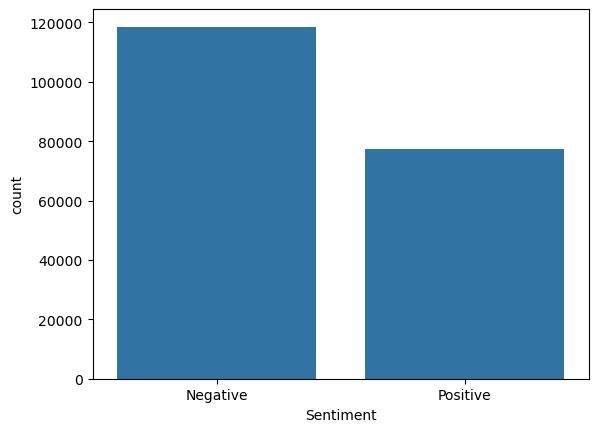

In [54]:
sns.barplot(data=a )

# The sentiment distribution indicates that overall patient experience is favorable, with nearly 40% positive sentiment. However, the high proportion of neutral responses suggests opportunities for hospitals to improve service quality and convert neutral patients into positive advocates

# Inferential Statistics

In [55]:
df['Patient Survey Star Rating'].mean()

np.float64(3.1931826878434295)

# Z-Test

**The national average patient satisfaction star rating is 3.0. Test whether the mean star rating of hospitals in your dataset is significantly different from the national average at 95% confidence?**

In [56]:
from scipy import stats

# Population mean (national average)
pop_mean = 3.0
alpha    = 0.05

# Sample data
sample   = df['Patient Survey Star Rating'].dropna()
x_bar    = sample.mean()
std      = sample.std()
n        = len(sample)

# Z-Test
z_stat = (x_bar - pop_mean) / (std / np.sqrt(n))
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f'Sample Mean : {x_bar}')
print(f'Z-Statistic : {z_stat}')
print(f'P-Value     : {p_value}')

if p_value < alpha:
    print('Reject H₀ — Mean rating is significantly different from 3.0')
else:
    print('Accept H₀ — Mean rating is NOT significantly different from 3.0')

Sample Mean : 3.1931826878434295
Z-Statistic : 85.81809042816161
P-Value     : 0.0
Reject H₀ — Mean rating is significantly different from 3.0


#  One Sample T-Test — Hospital Overall Rating 

**A healthcare report claims the average hospital overall rating is 3.5 stars. Test whether your dataset supports this claim at 95% confidence level.?**

In [57]:
from scipy.stats import ttest_1samp

alpha    = 0.05
pop_mean = 3.5

sample = df['Hospital overall rating'].dropna()

t_stat, p_value = ttest_1samp(sample, pop_mean)

print(f'Sample Mean : {sample.mean():.4f}')
print(f'T-Statistic : {t_stat:.4f}')
print(f'P-Value     : {p_value:.4f}')

if p_value < alpha:
    print('Reject H₀ — Hospital rating is significantly different from 3.5')
else:
    print('Accept H₀ — Hospital rating is NOT significantly different from 3.5')

Sample Mean : 3.1079
T-Statistic : -168.8029
P-Value     : 0.0000
Reject H₀ — Hospital rating is significantly different from 3.5


# One Sample T-Test---Hospital Overall Rating

**Do hospitals with emergency services have significantly higher patient satisfaction ratings than hospitals without emergency services? Test at 95% confidence level?**

In [58]:
from scipy.stats import ttest_ind

alpha = 0.05

emergency     = df[df['Emergency Services'] == 'Yes']['Patient Survey Star Rating'].dropna()
non_emergency = df[df['Emergency Services'] == 'No']['Patient Survey Star Rating'].dropna()

t_stat, p_value = ttest_ind(emergency, non_emergency, equal_var=False)

print(f'Emergency Mean     : {emergency.mean():.4f}')
print(f'Non-Emergency Mean : {non_emergency.mean():.4f}')
print(f'T-Statistic        : {t_stat:.4f}')
print(f'P-Value            : {p_value:.4f}')

if p_value < alpha:
    print('Reject H₀ — Significant difference exists between emergency and non-emergency hospitals')
else:
    print('Accept H₀ — No significant difference between emergency and non-emergency hospitals')

Emergency Mean     : 3.1678
Non-Emergency Mean : 3.6466
T-Statistic        : -40.4652
P-Value            : 0.0000
Reject H₀ — Significant difference exists between emergency and non-emergency hospitals


# ANOVA Test — Hospital Type Comparison

**Is there a significant difference in patient satisfaction ratings across different hospital types (Acute Care, Critical Access, Children's etc.)? Test at 95% confidence level?**

In [59]:
from scipy.stats import f_oneway

alpha = 0.05

groups = []
for htype in df['Hospital Type'].unique():
    group = df[df['Hospital Type'] == htype]['Patient Survey Star Rating'].dropna()
    groups.append(group)
    print(f'{htype} — Mean: {group.mean()}')

f_stat, p_value = f_oneway(*groups)

print(f'\nF-Statistic : {f_stat}')
print(f'P-Value     : {p_value}')

if p_value < alpha:
    print('Reject H₀ — Significant difference exists across hospital types')
else:
    print('Accept H₀ — No significant difference across hospital types')

Acute Care Hospitals — Mean: 3.081322667167499
Critical Access Hospitals — Mean: 3.9369629776281925
Acute Care - Department of Defense — Mean: 3.950413223140496

F-Statistic : 8962.411773856506
P-Value     : 0.0
Reject H₀ — Significant difference exists across hospital types


# Paired T-Test -- Year Over Year Comparison

**Did patient satisfaction ratings significantly improve from 2016 to 2020? Test at 95% confidence level?**

In [60]:
from scipy.stats import ttest_rel

alpha = 0.05

# Get ratings for 2016 and 2020 — merge on Facility ID
df_2016 = df[df['Year'] == 2016][['Facility ID', 'Patient Survey Star Rating']].dropna()
df_2020 = df[df['Year'] == 2020][['Facility ID', 'Patient Survey Star Rating']].dropna()

merged = pd.merge(df_2016, df_2020, on='Facility ID', suffixes=('_2016', '_2020'))

t_stat, p_value = ttest_rel(
    merged['Patient Survey Star Rating_2016'],
    merged['Patient Survey Star Rating_2020']
)

print(f'Mean Rating 2016 : {merged["Patient Survey Star Rating_2016"].mean():.4f}')
print(f'Mean Rating 2020 : {merged["Patient Survey Star Rating_2020"].mean():.4f}')
print(f'T-Statistic      : {t_stat:.4f}')
print(f'P-Value          : {p_value:.4f}')

if p_value < alpha:
    print('Reject H₀ — Significant improvement in ratings from 2016 to 2020')
else:
    print('Accept H₀ — No significant improvement from 2016 to 2020')

Mean Rating 2016 : 3.1909
Mean Rating 2020 : 3.1387
T-Statistic      : 35.8496
P-Value          : 0.0000
Reject H₀ — Significant improvement in ratings from 2016 to 2020


# Machine learnings algorithms

In [61]:
df.head()

,Facility ID,Facility Name,Address,City,State,ZIP Code,County Name,Phone Number,HCAHPS Measure ID,HCAHPS Question,HCAHPS Answer Description,Patient Survey Star Rating,Patient Survey Star Rating Footnote,HCAHPS Answer Percent,HCAHPS Answer Percent Footnote,HCAHPS Linear Mean Value,Number of Completed Surveys,Number of Completed Surveys Footnote,Survey Response Rate Percent,Survey Response Rate Percent Footnote,Start Date,End Date,Year,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for promoting interoperability of EHRs,Hospital overall rating,Hospital overall rating footnote,Mortality national comparison,Mortality national comparison footnote,Safety of care national comparison,Safety of care national comparison footnote,Readmission national comparison,Readmission national comparison footnote,Patient experience national comparison,Patient experience national comparison footnote,Effectiveness of care national comparison,Effectiveness of care national comparison footnote,Timeliness of care national comparison,Timeliness of care national comparison footnote,Efficient use of medical imaging national comparison,Efficient use of medical imaging national comparison footnote,Sentiment
0,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_STAR_RATING,Summary star rating,Summary star rating,3.0,NaN,Not Applicable,NaN,Not Applicable,1213,NaN,27.0,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN,Negative
5,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_CLEAN_STAR_RATING,Cleanliness - star rating,Cleanliness - star rating,2.0,NaN,Not Applicable,NaN,Not Applicable,1213,NaN,27.0,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN,Negative
9,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_COMP_1_STAR_RATING,Nurse communication - star rating,Nurse communication - star rating,3.0,NaN,Not Applicable,NaN,Not Applicable,1213,NaN,27.0,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN,Negative
14,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_COMP_2_STAR_RATING,Doctor communication - star rating,Doctor communication - star rating,3.0,NaN,Not Applicable,NaN,Not Applicable,1213,NaN,27.0,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN,Negative
19,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_COMP_3_STAR_RATING,Staff responsiveness - star rating,Staff responsiveness - star rating,2.0,NaN,Not Applicable,NaN,Not Applicable,1213,NaN,27.0,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,b

In [62]:
df.isnull().sum()

Facility ID                                                         363
Facility Name                                                         0
Address                                                               0
City                                                                  0
State                                                                 0
ZIP Code                                                              0
County Name                                                         140
Phone Number                                                      74151
HCAHPS Measure ID                                                     0
HCAHPS Question                                                       0
HCAHPS Answer Description                                             0
Patient Survey Star Rating                                            0
Patient Survey Star Rating Footnote                              196001
HCAHPS Answer Percent                                           

In [63]:
df.drop('Patient Survey Star Rating', axis=1, inplace= True )

In [64]:
df.rename(columns={'Sentiment': 'Patient rating Classification'}, inplace=True)

In [65]:
df.head()

,Facility ID,Facility Name,Address,City,State,ZIP Code,County Name,Phone Number,HCAHPS Measure ID,HCAHPS Question,HCAHPS Answer Description,Patient Survey Star Rating Footnote,HCAHPS Answer Percent,HCAHPS Answer Percent Footnote,HCAHPS Linear Mean Value,Number of Completed Surveys,Number of Completed Surveys Footnote,Survey Response Rate Percent,Survey Response Rate Percent Footnote,Start Date,End Date,Year,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for promoting interoperability of EHRs,Hospital overall rating,Hospital overall rating footnote,Mortality national comparison,Mortality national comparison footnote,Safety of care national comparison,Safety of care national comparison footnote,Readmission national comparison,Readmission national comparison footnote,Patient experience national comparison,Patient experience national comparison footnote,Effectiveness of care national comparison,Effectiveness of care national comparison footnote,Timeliness of care national comparison,Timeliness of care national comparison footnote,Efficient use of medical imaging national comparison,Efficient use of medical imaging national comparison footnote,Patient rating Classification
0,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_STAR_RATING,Summary star rating,Summary star rating,NaN,Not Applicable,NaN,Not Applicable,1213,NaN,27.0,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN,Negative
5,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_CLEAN_STAR_RATING,Cleanliness - star rating,Cleanliness - star rating,NaN,Not Applicable,NaN,Not Applicable,1213,NaN,27.0,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN,Negative
9,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_COMP_1_STAR_RATING,Nurse communication - star rating,Nurse communication - star rating,NaN,Not Applicable,NaN,Not Applicable,1213,NaN,27.0,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN,Negative
14,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_COMP_2_STAR_RATING,Doctor communication - star rating,Doctor communication - star rating,NaN,Not Applicable,NaN,Not Applicable,1213,NaN,27.0,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,NaN,same as the national average,NaN,same as the national average,NaN,same as the national average,NaN,Negative
19,10001.0,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3.347939e+09,H_COMP_3_STAR_RATING,Staff responsiveness - star rating,Staff responsiveness - star rating,NaN,Not Applicable,NaN,Not Applicable,1213,NaN,27.0,NaN,04/01/2015,03/31/2016,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,NaN,same as the national average,NaN,above the national average,NaN,same as the national average,NaN,below the national average,N

In [66]:
df.drop(columns=['Facility ID','Facility Name','Address','ZIP Code','County Name','Phone Number','HCAHPS Measure ID','HCAHPS Answer Description','HCAHPS Answer Percent Footnote','Start Date',
                'End Date','Hospital overall rating footnote','Mortality national comparison footnote','Safety of care national comparison footnote','Readmission national comparison footnote',
                'Patient experience national comparison footnote', 'Effectiveness of care national comparison footnote','Timeliness of care national comparison footnote',
                'Efficient use of medical imaging national comparison footnote','HCAHPS Answer Percent Footnote','Number of Completed Surveys Footnote'] , inplace= True )

In [67]:
df.drop(columns=['HCAHPS Question','Patient Survey Star Rating Footnote','Survey Response Rate Percent Footnote','HCAHPS Answer Percent'], inplace=True)

In [68]:
df.head()

,City,State,HCAHPS Linear Mean Value,Number of Completed Surveys,Survey Response Rate Percent,Year,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for promoting interoperability of EHRs,Hospital overall rating,Mortality national comparison,Safety of care national comparison,Readmission national comparison,Patient experience national comparison,Effectiveness of care national comparison,Timeliness of care national comparison,Efficient use of medical imaging national comparison,Patient rating Classification
0,DOTHAN,AL,Not Applicable,1213,27.0,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,same as the national average,above the national average,same as the national average,below the national average,same as the national average,same as the national average,same as the national average,Negative
5,DOTHAN,AL,Not Applicable,1213,27.0,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,same as the national average,above the national average,same as the national average,below the national average,same as the national average,same as the national average,same as the national average,Negative
9,DOTHAN,AL,Not Applicable,1213,27.0,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,same as the national average,above the national average,same as the national average,below the national average,same as the national average,same as the national average,same as the national average,Negative
14,DOTHAN,AL,Not Applicable,1213,27.0,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,same as the national average,above the national average,same as the national average,below the national average,same as the national average,same as the national average,same as the national average,Negative
19,DOTHAN,AL,Not Applicable,1213,27.0,2016,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3.0,same as the national average,above the national average,same as the national average,below the national average,same as the national average,same as the national average,same as the national average,Negative


In [69]:
df.isnull().sum()

City                                                         0
State                                                        0
HCAHPS Linear Mean Value                                     0
Number of Completed Surveys                                  0
Survey Response Rate Percent                                 0
Year                                                         0
Hospital Type                                                0
Hospital Ownership                                           0
Emergency Services                                           0
Meets criteria for promoting interoperability of EHRs    10634
Hospital overall rating                                  10356
Mortality national comparison                                0
Safety of care national comparison                           0
Readmission national comparison                              0
Patient experience national comparison                       0
Effectiveness of care national comparison              

In [70]:
df.dropna(inplace=True)

In [71]:
df.shape

(176897, 19)

In [72]:
from sklearn.preprocessing import LabelEncoder , StandardScaler

In [73]:
le=LabelEncoder()
for cols in df.columns:
    df[cols]=le.fit_transform(df[cols])

In [74]:
df.head()

,City,State,HCAHPS Linear Mean Value,Number of Completed Surveys,Survey Response Rate Percent,Year,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for promoting interoperability of EHRs,Hospital overall rating,Mortality national comparison,Safety of care national comparison,Readmission national comparison,Patient experience national comparison,Effectiveness of care national comparison,Timeliness of care national comparison,Efficient use of medical imaging national comparison,Patient rating Classification
0,492,1,0,234,21,0,0,1,1,0,2,3,0,3,1,3,3,3,0
5,492,1,0,234,21,0,0,1,1,0,2,3,0,3,1,3,3,3,0
9,492,1,0,234,21,0,0,1,1,0,2,3,0,3,1,3,3,3,0
14,492,1,0,234,21,0,0,1,1,0,2,3,0,3,1,3,3,3,0
19,492,1,0,234,21,0,0,1,1,0,2,3,0,3,1,3,3,3,0


In [75]:
df.columns

Index(['City', 'State', 'HCAHPS Linear Mean Value',
       'Number of Completed Surveys', 'Survey Response Rate Percent', 'Year',
       'Hospital Type', 'Hospital Ownership', 'Emergency Services',
       'Meets criteria for promoting interoperability of EHRs',
       'Hospital overall rating', 'Mortality national comparison',
       'Safety of care national comparison', 'Readmission national comparison',
       'Patient experience national comparison',
       'Effectiveness of care national comparison',
       'Timeliness of care national comparison',
       'Efficient use of medical imaging national comparison',
       'Patient rating Classification'],
      dtype='object')

# Regression Analysis

In [76]:
x=df.drop('Patient rating Classification',axis=1)
y=df['Patient rating Classification']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics   import *
from imblearn.over_sampling import SMOTE

x_train,x_test , y_train , y_test = train_test_split(x,y,test_size=0.30 , random_state=42)
smote = SMOTE(random_state=42)  # as the class is imbalance so we will use smote tech to provide synthetic data to the model on the less data category 
X_train_res, y_train_res = smote.fit_resample(x_train, y_train)

#Train Logistic Regression
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_res, y_train_res)

y_pred=model.predict(x_test)
print('Accuracy :', round(accuracy_score(y_test,y_pred)*100,2))

Accuracy : 72.77


Confusion Matrix:
 [[29404  4069]
 [ 4926 14671]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87     33473
           1       0.78      0.75      0.77     19597

    accuracy                           0.83     53070
   macro avg       0.82      0.81      0.82     53070
weighted avg       0.83      0.83      0.83     53070



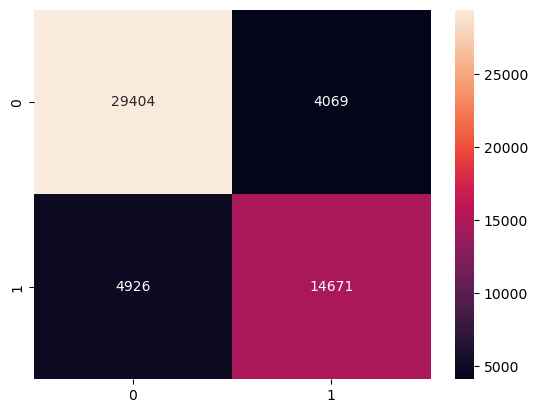

In [101]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
sns.heatmap(cm,fmt='.0f', annot=True)

# Classification Report (better view)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Extreme Gradient Boosting

Accuracy : 78.97343131712832
Confusion Matrix:
 [[22338  5643]
 [ 3656 12588]]


<Axes: >

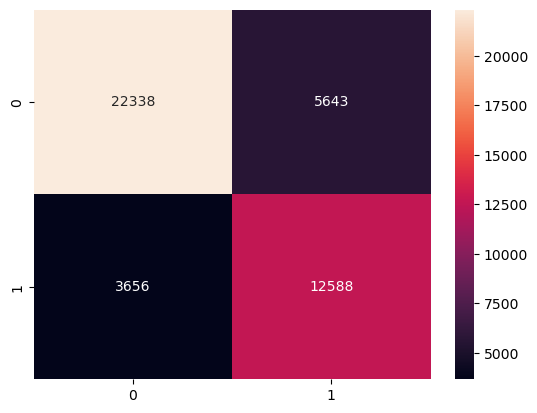

In [103]:
from xgboost import XGBClassifier
x_train,x_test , y_train , y_test = train_test_split(x,y,test_size=0.25 , random_state=42)

xgb = XGBClassifier(n_estimators=200, learning_rate=0.1)
xgb.fit(X_train_res, y_train_res)

y_pred = xgb.predict(x_test)
print('Accuracy :' ,accuracy_score(y_test, y_pred)*100)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
sns.heatmap(cm,fmt='.0f', annot=True)


# Random Forest Classification

In [80]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=150 , random_state= 42)
rfe=RFE(estimator=rf , n_features_to_select= 6)
rfe=rfe.fit(x,y)

In [81]:
selected_features = [feature for feature, selected in zip(x, rfe.support_) if selected]
selected_features

['City',
 'State',
 'Number of Completed Surveys',
 'Survey Response Rate Percent',
 'Hospital overall rating',
 'Patient experience national comparison']

In [86]:
X = df[selected_features]   # columns selected by RFE
y = df["Patient rating Classification"] 
y_pred=rfe.predict(x_test)
print('Accuracy :',accuracy_score(y_test, y_pred)*100 )
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy : 83.05068777086866

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87     33473
           1       0.78      0.75      0.77     19597

    accuracy                           0.83     53070
   macro avg       0.82      0.81      0.82     53070
weighted avg       0.83      0.83      0.83     53070



<Axes: >

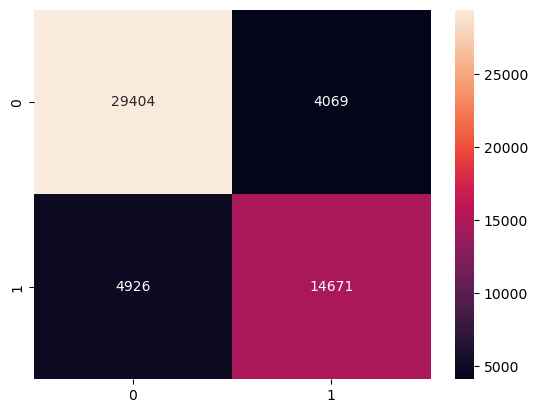

In [100]:
cm = confusion_matrix(y_test,y_pred).round(0)
sns.heatmap(cm,fmt='.0f', annot=True)